In [43]:
import sklearn
import pandas as pd
import numpy as np
from numpy import errstate,isneginf
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as sc

from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier

import xgboost as xgb
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, precision_score, recall_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from tqdm import tqdm
from tqdm import trange
from collections import Counter

from sklearn.decomposition import PCA

#import umap

import zipfile
import os
import json
import requests
import io
import copy
#import biomart
#import umap


~30 seconds to read TCGA data, ~7 seconds to read STMFR data

In [36]:
import logging
logger = logging.getLogger()
logger.setLevel(logging.DEBUG) # process everything, even if everything isn't printed

fh = logging.FileHandler('myLog.log')
fh.setLevel(logging.DEBUG) # or any level you want
logger.addHandler(fh)

In [3]:
tcga_file_path = '/Users/bhavesh/Library/CloudStorage/GoogleDrive-bhavesh.neekhra_phd18@ashoka.edu.in/My Drive/CR_Data/Data/tcga_final_data.csv'

# tcga_file_path = '/home/swapnanil_mukherjee/cancer_data/tcga_final_data.csv'

tcga = pd.read_csv(tcga_file_path)

In [48]:
# stmfr_file_path = '/home/bhavesh/Documents/PhD/model_agreement_expr/stmfr_4_classes.csv'

stmfr_file_path = '/Users/bhavesh/Library/CloudStorage/GoogleDrive-bhavesh.neekhra_phd18@ashoka.edu.in/My Drive/CR_Data/Data/stmfr_4_classes.csv'
df= pd.read_csv(stmfr_file_path)

# print(df.shape)


df.set_index(df.loc[:, '0'], inplace=True)
df.drop('0', axis=1, inplace=True)

In [5]:
tcga.set_index(tcga.loc[:, "Unnamed: 0"], inplace=True)
tcga.drop("Unnamed: 0", axis=1, inplace=True)
cols = df.columns.tolist()
cols_ = cols[:-1]

tcga = tcga[cols_]

In [49]:
tcga.shape

(11070, 11980)

In [ ]:
# print(df['label'].value_counts())

In [50]:
label_encoder = LabelEncoder()
df['numeric_label'] = label_encoder.fit_transform(df.label)
df.drop('label', axis=1, inplace=True)

In [51]:
print(df['numeric_label'].value_counts())
print(label_encoder.classes_)

numeric_label
1    997
3    896
2    816
0    585
Name: count, dtype: int64
['hESC' 'hMSC' 'hUSC' 'iPSC']


In [52]:
global box_plot_num 
box_plot_num = 0
global model_prediction_agreement 
model_prediction_agreement = 0

In [53]:
# Creating plot
# plt.boxplot(model_acc_list, patch_artist = True,
#                 notch ='True', vert = 0)
def box_plot_models_accuracy(model_acc_list):

    plt.rcParams.update({'font.size': 8})


    global box_plot_num
    # fig = plt.figure(figsize =(6, 4))    
    plt.boxplot(model_acc_list, vert = 0, )

    plt.xlabel("accuracy")
    # plt.title('PCA with 500 components\n 90-10 data split')   # Change the font setting for the title 
    fname = 'boxplot_'+str(box_plot_num)+'.png'
    box_plot_num = box_plot_num + 1
    plt.savefig(fname)
    plt.close()


In [54]:
def get_agreement_rate(model_pred, n_models, len_tcga):

    model_pred_results = pd.DataFrame(model_pred)
    # model_pred_results.to_csv("model_agreements.csv", index=False)
    model_pred_results_len = len(model_pred_results.columns)
    min_agree_list = []

    count_models = n_models # For prototyping use 5, and change it back to 100
    samples_index = []

    low = np.int16(np.ceil(0.4*count_models))
    high = count_models + 1

    

    # for min in range(40,101):
    for min in range(low,high):     
        c = 0
        for i in range(model_pred_results_len):
            counter_values = list(Counter(model_pred_results[i]).values())
            if any(j >= min for j in counter_values):
                c+=1
                if(min == count_models):
                    samples_index.append([i, model_pred_results[i][0]])
                    # print (i, model_pred_results[i])
        agree_score = c/len_tcga
        min_agree_list.append([min, agree_score])

    min_agree_df = pd.DataFrame(min_agree_list)

    return samples_index, min_agree_df

In [55]:
def plot_model_accuracy(min_agree_df, len_train, len_test, len_ood):

    global model_prediction_agreement
    x = min_agree_df[0]
    y = min_agree_df[1]

    # make data
    # x = np.linspace(0, 10, 100)
    # y = 4 + 2 * np.sin(2 * x)

    # plot
    fig, ax = plt.subplots()

    ax.plot(x, y, linewidth=2.0)

    # ax.set(xlim=(0, 100),
    #        ylim=(0, 1.1),)

    for i,j in zip(x,y):
        if(i in (40, 60, 70, 80, 90, 100)):
            ax.annotate(f"{j:.1%}",xy=(i,j))


    ax.set(ylim=(0, 1.1))
    plt.xlabel('Number of models')
    plt.ylabel('% agreement')
    plt.title('Train: '+str(len_train)+' Test: '+str(len_test)+' OOD: '+str(len_ood))
    fname = 'model_agreement_percent_'+str(model_prediction_agreement)+'.png'
    model_prediction_agreement = model_prediction_agreement + 1
    plt.savefig(fname)
    plt.close()

In [56]:
def merge_samples_tcga_stmfr(samples_index, stmfr_df, tcga_df):
    
    samples_index_df = pd.DataFrame(samples_index)
    # samples_index_df
    selected_tcga_samples = tcga_df.iloc[samples_index_df[0]]
    
    ood_index = list(set(range(len(tcga_df))) - set(samples_index_df[0]))
    
    ood_tcga_samples = tcga_df.iloc[ood_index]

    selected_tcga_samples.loc[:,"numeric_label"] = list(samples_index_df[1])

    if len(selected_tcga_samples) == 1:
        combined_train_stmfr_tcga = pd.concat([stmfr_df, selected_tcga_samples])
        return combined_train_stmfr_tcga, "", ood_tcga_samples
    else:
        selected_tcga_samples_train, selected_tcga_samples_test = train_test_split(selected_tcga_samples, test_size=0.2, random_state=42, shuffle=True) 
        combined_train_stmfr_tcga = pd.concat([stmfr_df, selected_tcga_samples_train])
        return combined_train_stmfr_tcga, selected_tcga_samples_test, ood_tcga_samples

In [ ]:
# !pip install hyperopt

In [13]:
# import hyperopt.pyll.stochastic

# print(hyperopt.pyll.stochastic.sample(space))

In [67]:
# import xgboost as xgb
# from hyperopt import fmin, tpe, hp
# from hyperopt import STATUS_OK

# # Define the hyperparameter space
# space = {
#     'max_depth': hp.uniformint('max_depth', 2, 8),
#     'learning_rate': hp.loguniform('learning_rate', -5, -2),
#     'subsample': hp.uniform('subsample', 0.5, 1)
# }

# train, test = train_test_split(df, test_size=0.1, random_state=42, shuffle=True)

# # train, test = train_test_split(stmfr_data_train, test_size=0.1, random_state=i, shuffle=True)

# X_train, y_train = train.iloc[:, :-1], train['numeric_label']
# X_test, y_test = test.iloc[:, :-1], test['numeric_label']

# # Define the objective function to minimize
# def objective(params):
#     xgb_model = xgb.XGBClassifier(**params)
#     xgb_model.fit(X_train, y_train)
#     y_pred = xgb_model.predict(X_test)
#     score = accuracy_score(y_test, y_pred)
#     return {'loss': -score, 'status': STATUS_OK}

# # Perform the optimization
# best_params = fmin(objective, space, algo=tpe.suggest, max_evals=10)
# print("Best set of hyperparameters: ", best_params)

100%|██████████| 10/10 [1:06:49<00:00, 400.95s/trial, best loss: -0.9575757575757575]  
Best set of hyperparameters:  {'learning_rate': 0.11716612264320947, 'max_depth': 4.0, 'subsample': 0.8195573834624639}


hyperopt with 10 evaluations, for XGBoost, Best set of hyperparameters:  {'learning_rate': 0.11716612264320947, 'max_depth': 4.0, 'subsample': 0.8195573834624639}
                                                            
                                                            default: eta [default=0.3, alias: learning_rate], max_depth [default=6], subsample [default=1] 
                                                                        (Source: https://xgboost.readthedocs.io/en/release_0.82/parameter.html)

In [14]:
 # import warnings
# with warnings.catch_warnings():
#     warnings.simplefilter("ignore")   /. 

# from sklearn.preprocessing import MinMaxScaler, StandardScaler
# train, test = train_test_split(df, test_size=0.3, random_state=42, shuffle=True)

# train, test = train_test_split(stmfr_data_train, test_size=0.1, random_state=i, shuffle=True)

# X_train, y_train = train.iloc[:, :-1], train['numeric_label']
# X_test, y_test = test.iloc[:, :-1], test['numeric_label']

x = df.iloc[:, :-1]
y = df['numeric_label']

# scaler = StandardScaler()

# x_rescaled = pd.DataFrame(scaler.fit_transform(x), index=x.index, columns=x.columns)

acc_list = []
b_acc_list = []
f1_list = []
prec_list = []
rec_list = []

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for train_index, test_index in skf.split(x, y):
    
    X_train, X_test = x.iloc[train_index], x.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # bst = XGBClassifier(n_estimators=2, max_depth=20, learning_rate=1, num_class=4, objective='multi:softmax')
    # model = XGBClassifier(num_class=4, objective='multi:softmax', max_depth=4, learning_rate=0.117, subsample=0.82)

    model = LogisticRegression(n_jobs=-1, max_iter=250)
    

    # pca = PCA(n_components=0.99)
    # X_train_pca = pca.fit_transform(X_train)
    # X_test_pca = pca.transform(X_test)

    # fit model
    model.fit(X_train, y_train)
    # make predictions
    predictions = model.predict(X_test)

    # dtrain = xgb.DMatrix(X_train_pca, label=y_train)
    # dtrain.save_binary('train.buffer')

    # param = {'max_depth': 20, 'eta': 1, 'objective': 'multi:softmax'}
    # param['nthread'] = 4
    # param['eval_metric'] = 'auc'
    # param['num_class'] = 4

    # num_round = 10
    # bst = xgb.train(param, dtrain, num_round)

    # dtest = xgb.DMatrix(X_test_pca)
    # predictions = bst.predict(dtest)

    target_names = ['hESC', 'hMSC', 'hUSC', 'iPSC']
    # print(classification_report(y_test, predictions, target_names=target_names))

    # model_acc = accuracy_score(y_test, predictions, normalize=True)
    # model_acc

    accuracy = accuracy_score(y_test, predictions)
    acc_list.append(accuracy)

    b_accuracy = balanced_accuracy_score(y_test, predictions)
    b_acc_list.append(b_accuracy)

    f1score = f1_score(y_test, predictions, average='weighted')
    f1_list.append(f1score)

    precision = precision_score(y_test, predictions, average='weighted')
    prec_list.append(precision)

    recall = recall_score(y_test, predictions, average='weighted')
    rec_list.append(recall)

    print(accuracy, end='\t')
    print(b_accuracy, end='\t')
    print(f1score, end='\t')
    print(precision, end='\t')
    print(recall)

    # break

print("Average for 5-fold cross-validation:\n")

print("Accuracy: ", np.average(acc_list), end='\t')
print("Balanced Accuracy: ", np.average(b_acc_list), end='\t')
print("F1 score: ", np.average(f1_list), end='\t')
print("Precision: ", np.average(prec_list), end='\t')
print("Recall: ", np.average(rec_list))
    # xgb.plot_importance(bst)
    # xgb.plot_tree(bst, num_trees=2)
    # xgb.to_graphviz(bst, num_trees=2)

/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.9742033383915023	0.9710129004844876	0.974213351565101	0.9749117927579526	0.9742033383915023


/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.9833080424886191	0.97919150804887	0.9832091404321182	0.9835227995571906	0.9833080424886191


/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.9650986342943855	0.9650818965299547	0.9650908504377667	0.9655350689942175	0.9650986342943855


/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.9802731411229135	0.9784816932441558	0.9802370755961248	0.9803874217786325	0.9802731411229135


/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.9802431610942249	0.9790366150926623	0.9802101776633007	0.9803053402497163	0.9802431610942249


Source: https://mikulskibartosz.name/pca-how-to-choose-the-number-of-components 

For PCA = variance required

Default setting of XGBoost (What is it for n_estimators (100?), max_depth (3?), learning rate (?)

Max depth = 20, 90/10
with all features Xgboost acc = 94.55
with 100 PCA , 0.9363636363636364 , 0.9545454545454546 , 0.9575757575757575, 0.9515151515151515
with 55 PCA, 0.9424242424242424


70/30

100 PCA , 0.9332659251769464 , 0.9362992922143579 

Max depth = 20, 70/30, w/o PCA,0.9433771486349848, 2m 34.2s
Max depth = 20, 70/30, 100 PCA,0.9332659251769464, 58.2s, 0.9322548028311426(45.0s)

In [14]:
df

,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001167,ENSG00000001460,ENSG00000001461,...,ENSG00000266964,ENSG00000267080,ENSG00000267120,ENSG00000267281,ENSG00000267534,ENSG00000267629,ENSG00000267680,ENSG00000267740,ENSG00000267796,numeric_label
0,,,,,,,,,,,,,,,,,,,,,
7350_GSM2871131,-0.662465,-0.452173,-1.366386,-0.957116,-0.582066,-1.206935,-1.446136,-0.281347,-0.963616,-1.147786,...,-0.691654,-0.740644,-0.543299,-0.861714,-0.663446,-0.226101,-0.660147,-1.659454,-1.229186,0
7350_GSM2871132,-0.487142,-1.025886,-1.330880,-1.142515,-0.686235,-1.185022,-1.446136,-0.157531,-1.039952,-1.426006,...,-0.990348,-0.514260,-0.634073,-0.863995,-0.772662,-0.063450,-0.661335,-1.632080,-1.072617,0
7350_GSM2871133,-0.481782,-0.416273,-1.253671,-0.808227,-0.543173,-1.277043,-1.446136,-0.171315,-0.944330,-0.594480,...,-1.574552,-0.447816,-0.490658,-0.803086,-0.846506,-0.305177,-0.570313,-1.517048,-1.193821,0
7350_GSM2871134,-0.610746,-0.161556,-1.131855,-0.942407,-0.740700,-1.216042,-1.446136,-0.112961,-0.969344,-0.736165,...,-1.586824,-0.447225,-0.596967,-0.795399,-0.871276,-0.684173,-0.538042,-1.594537,-1.339423,0
7350_GSM2871135,-0.483981,-0.420357,-1.224028,-0.975168,-0.732516,-1.375678,-1.446136,-0.268023,-0.926742,-1.068048,...,-1.501507,-0.250528,-0.416236,-0.800702,-0.845996,-0.311442,-0.559322,-1.484994,-1.054173,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6247_GSM1110013,1.822663,0.160126,1.053751,2.114667,2.268519,1.394913,0.074945,0.702325,1.095318,1.190563,...,1.139332,1.101247,2.746945,1.692899,1.753043,0.162365,0.515832,1.647766,1.721268,0
6247_GSM1110014,1.723191,0.786154,1.041834,2.058606,2.209260,1.334271,-0.226192,0.633843,0.885527,1.091937,...,1.257297,1.154335,2.690416,1.755970,1.863545,0.293591,0.527822,1.560856,1.545243,0
6247_GSM1110015,1.773102,0.875817,1.051819,2.015303,2.163488,1.536715,-0.187924,0.597069,1.103763,1.187287,...,1.149815,1.170515,2.737587,1.662613,1.841696,0.403886,0.337838,1.611271,1.594028,0


In [86]:
def prediction_agreement_models(stmfr_df, tcga_df, held_out_data = "", n_models = 100, pca = False, pca_n_components = 100):

    n = n_models
    model_acc_list = []
    val_acc_list = []
    model_pred = []
    df = stmfr_df
    tcga = tcga_df

    val_data = False

    # pca_n_comps = [1, 5, 10, 50, 100, 500, 1000, 2000]
    # pca_n_comps = [200, 300, 400, 600, 700, 800, 900]

    for i in tqdm(range(n)):
    # for i in pca_n_comps:
        train, test = train_test_split(df, test_size=0.2, random_state=i, shuffle=True)

        # train, test = train_test_split(stmfr_data_train, test_size=0.1, random_state=i, shuffle=True)

        X_train, y_train = train.iloc[:, :-1], train['numeric_label']
        X_test, y_test = test.iloc[:, :-1], test['numeric_label']

        # scaler = preprocessing.StandardScaler().fit(X_train)
        # pipe = make_pipeline(StandardScaler(), LinearSVC(dual = True, max_iter=10000))
        # pipe.fit(X_train, y_train)
        # pipe.score(X_test, y_test)

        # print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)
        if pca:
                
            pca = PCA(n_components=pca_n_components)
            X_train_pca = pca.fit_transform(X_train)
            X_test_pca = pca.transform(X_test)
            tcga_pca = pca.transform(tcga)
            
            # model = LinearSVC(dual = False, max_iter=10000)
        else:
            X_train_pca = X_train
            X_test_pca = X_test
            tcga_pca = tcga

            # model = LinearSVC(dual = True, max_iter=10000)
        
        model = LogisticRegression(n_jobs=-1, max_iter=250)
        
        # model_coeffs = model.coef_
        # mlp_model = MLPClassifier(hidden_layer_sizes=[10, 10], solver='sgd', batch_size=256, max_iter=100)

        # dtrain = xgb.DMatrix(X_train_pca, label=y_train)
        # # dtrain.save_binary('train.buffer')

        # param = {'max_depth': 20, 'eta': 1, 'objective': 'multi:softmax'}
        # param['nthread'] = 4
        # param['eval_metric'] = 'auc'
        # param['num_class'] = 4

        # num_round = 10
        # model = xgb.train(param, dtrain, num_round)

        # dtest = xgb.DMatrix(X_test_pca)
        # predictions = model.predict(dtest)

        model.fit(X_train_pca, y_train)
        predictions = model.predict(X_test_pca)

        try:   
            if not held_out_data.empty:
                val_data = True
                X_validation, y_validation = held_out_data.iloc[:, :-1], held_out_data['numeric_label']
                if pca:
                    X_validation_pca = pca.transform(X_validation)
                else:
                    X_validation_pca = X_validation

                # dvalid = xgb.DMatrix(X_validation_pca)
                # validation_prediction = model.predict(dvalid)
                validation_prediction = model.predict(X_validation_pca)
                validation_prediction_acc = accuracy_score(y_validation, validation_prediction, normalize=True)
                val_acc_list.append(validation_prediction_acc)
                if(i%10 == 0):
                    logger.info("For "+str(i)+" model's accuracy on heldout OOD data: "+str(validation_prediction_acc))
        except Exception as e:
            #Handle the exception
            # print("An exception occurred: ", e)
            # logging.warning("An exception occurred: ")
            # logging.warning(e) 
            pass

        # report = classification_report(y_test, predictions, output_dict=True)
        model_acc = accuracy_score(y_test, predictions, normalize=True)
        model_acc_list.append(model_acc)

        # print("For", i, "LinearSVC accuracy: ", model_acc)
        # dvalid = xgb.DMatrix(tcga_pca)
        # model_pred.append(model.predict(dvalid))

        model_pred.append(model.predict(tcga_pca))

        # model_pred.append(model.predict(stmfr_data_predict))

        # results = pd.DataFrame(report).transpose()
        # results = results.round({'precision': 2, 'recall': 2, 'f1-score': 2, 'support':1})
        # model.predict(tcga)
        

    logging.info("For "+str(n)+" models, test accuracy avg and stddev: "+str(np.mean(model_acc_list))+" "+str(np.std(model_acc_list)))
    if(val_data):
        logging.info("For "+str(n)+" models, validation accuracy (on held out OOD) avg and stddev: "+str(np.mean(val_acc_list))+" "+str(np.std(val_acc_list)))

    box_plot_models_accuracy(model_acc_list)
    samples_index, min_agree_df = get_agreement_rate(model_pred,n ,len(tcga))
    logging.info("Round 1: No of OOD samples for which labelling is done: "+str(len(samples_index)))
    plot_model_accuracy(min_agree_df, len(X_train), len(X_test), len(tcga))
    combined_train_stmfr_tcga, selected_tcga_samples_test, ood_tcga_samples = merge_samples_tcga_stmfr(samples_index, stmfr_df, tcga_df)
    
    
    return combined_train_stmfr_tcga, selected_tcga_samples_test, ood_tcga_samples

In [64]:

combined_train_stmfr_tcga, selected_tcga_samples_test, ood_tcga_samples = prediction_agreement_models(df, tcga, "", n_models=100)

logger.info("Length of combined_train_stmfr_tcga, selected_tcga_test, ood_tcga: "+
                str(len(combined_train_stmfr_tcga))+" "+str(len(selected_tcga_samples_test))+" "+str(len(ood_tcga_samples)))

  0%|          | 0/100 [00:00<?, ?it/s]/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
  1%|          | 1/100 [00:28<47:03, 28.53s/it]/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    h

In [65]:
combined_train_stmfr_tcga
# selected_tcga_samples_test, 
# ood_tcga_samples

,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001167,ENSG00000001460,ENSG00000001461,...,ENSG00000266964,ENSG00000267080,ENSG00000267120,ENSG00000267281,ENSG00000267534,ENSG00000267629,ENSG00000267680,ENSG00000267740,ENSG00000267796,numeric_label
7350_GSM2871131,-0.662465,-0.452173,-1.366386,-0.957116,-0.582066,-1.206935,-1.446136,-0.281347,-0.963616,-1.147786,...,-0.691654,-0.740644,-0.543299,-0.861714,-0.663446,-0.226101,-0.660147,-1.659454,-1.229186,0
7350_GSM2871132,-0.487142,-1.025886,-1.330880,-1.142515,-0.686235,-1.185022,-1.446136,-0.157531,-1.039952,-1.426006,...,-0.990348,-0.514260,-0.634073,-0.863995,-0.772662,-0.063450,-0.661335,-1.632080,-1.072617,0
7350_GSM2871133,-0.481782,-0.416273,-1.253671,-0.808227,-0.543173,-1.277043,-1.446136,-0.171315,-0.944330,-0.594480,...,-1.574552,-0.447816,-0.490658,-0.803086,-0.846506,-0.305177,-0.570313,-1.517048,-1.193821,0
7350_GSM2871134,-0.610746,-0.161556,-1.131855,-0.942407,-0.740700,-1.216042,-1.446136,-0.112961,-0.969344,-0.736165,...,-1.586824,-0.447225,-0.596967,-0.795399,-0.871276,-0.684173,-0.538042,-1.594537,-1.339423,0
7350_GSM2871135,-0.483981,-0.420357,-1.224028,-0.975168,-0.732516,-1.375678,-1.446136,-0.268023,-0.926742,-1.068048,...,-1.501507,-0.250528,-0.416236,-0.800702,-0.845996,-0.311442,-0.559322,-1.484994,-1.054173,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-KN-8419-01,-0.739475,-0.049936,-0.618992,-0.514123,-1.015328,-0.271837,-0.342792,-0.915653,-0.897204,0.001959,...,-0.348762,-1.146985,0.000000,0.000000,-0.655521,0.000000,-0.587062,0.000000,-0.945032,2
TCGA-ET-A39M-01,0.052046,-0.051600,-0.265918,-0.783015,-0.833770,0.134456,-0.219562,-0.609155,-0.011277,0.756655,...,-0.198130,0.735498,0.000000,0.000000,0.965760,0.000000,-1.054695,0.000000,0.572282,1
TCGA-CD-A4MG-01,-0.201947,-0.048401,1.163611,0.597205,-0.043441,0.093245,-0.205378,-0.463509,-0.737837,-0.177415,...,-0.300296,0.247899,0.000000,0.000000,-0.228149,0.000000,-0.252016,0.000000,0.660170,1
TCGA-21-5786-01,0.075375,-0.051600,0.190340,-0.836089,-0.009061,-0.237137,-0.206352,0.888763,0.091514,-0.705845,...,-0.337148,-0.158551,0.000000,0.000000,-0.041914,0.000000,-0.562553,0.000000,0.101000,0


2m 57.8s, 3 models, 100 PCA
For 3 models, test accuracy avg and stddev:  0.9555555555555556 0.01737843488291437
Length of combined_train_stmfr_tcga, selected_tcga_test, ood_tcga:  7009 929 6426

w/o PCA, 3 models 

In [ ]:
round = 2
while True:
    try:
        if len(ood_tcga_samples) >= 0.05*len(tcga):
            # logger.debug/info/warning/error
            logger.info("\nRound "+str(round)+" starts:\n")   
            logger.info("Length of combined_train_stmfr_tcga, selected_tcga_test, ood_tcga: "+
                str(len(combined_train_stmfr_tcga))+" "+str(len(selected_tcga_samples_test))+" "+str(len(ood_tcga_samples)))
            
            combined_train_stmfr_tcga, selected_tcga_samples_test, ood_tcga_samples = prediction_agreement_models(
                combined_train_stmfr_tcga, ood_tcga_samples, selected_tcga_samples_test, n_models=100)
            
            logger.info("\nRound "+str(round)+" Details:\n")   
            logger.info("Length of combined_train_stmfr_tcga, selected_tcga_test, ood_tcga: "+
                str(len(combined_train_stmfr_tcga))+" "+str(len(selected_tcga_samples_test))+" "+str(len(ood_tcga_samples)))
            
            tcga_curr_round_labelled = combined_train_stmfr_tcga.filter(like='TCGA', axis=0)
            tcga_curr_round_combined = pd.concat([tcga_curr_round_labelled, selected_tcga_samples_test])        
            logger.info(tcga_curr_round_combined.groupby(['numeric_label'])['numeric_label'].count())
            
            logger.info("\nRound "+str(round)+" ends.\n\n") 

            round = round + 1
            if len(selected_tcga_samples_test*4) <= 100:
                logger.info("No of selected TCGA samples for next round is less than 100")
                
                break
        else:
            logger.info("No of samples in OOD is less than 5% of the original")
            break
    except Exception as e:
        #Handle the exception
        logger.warning("An exception occurred:", e) #
        break
logger.info("Execution ended!!!\n")    

In [68]:
len(combined_train_stmfr_tcga), len(selected_tcga_samples_test), len(ood_tcga_samples)

(11378, 13, 962)

In [138]:
# combined_train_stmfr_tcga.to_csv("combined_STMFR_TCGA_1st_round.csv")

# selected_tcga_samples_test.to_csv("selected_TCGA_1st_round.csv")

In [69]:
# Forward experiment, in each round, in labeled TCGA, plot the distribution of labels

# Saving the labelled TCGA took ~ 1m 32.4s 

tcga_curr_round_labelled = combined_train_stmfr_tcga.filter(like='TCGA', axis=0)

tcga_curr_round_combined = pd.concat([tcga_curr_round_labelled, selected_tcga_samples_test])

tcga_curr_round_combined.to_csv("TCGA_labelled_18Dec23.csv")

In [79]:
#

# !ls /Users/bhavesh/Documents/AU/PhD/model_agreement_expr/19th_Dec/TCGA_labelled_18Dec23.csv

/Users/bhavesh/Documents/AU/PhD/model_agreement_expr/19th_Dec/TCGA_labelled_18Dec23.csv


# Reverse Experiment
# Use TCGA to label STMFR

In [80]:
# Took 18.9s to read from local 

tcga_labeled_df = pd.read_csv("/Users/bhavesh/Documents/AU/PhD/model_agreement_expr/19th_Dec/TCGA_labelled_18Dec23.csv")

In [87]:
tcga_labeled_df.shape

(8097, 11981)

In [82]:
tcga_labeled_df.set_index(tcga_labeled_df['Unnamed: 0'], inplace=True)
tcga_labeled_df.drop('Unnamed: 0', axis=1, inplace=True)

In [83]:
stmfr_unlabelled_df = df.iloc[:, :-1]

In [88]:
stmfr_unlabelled_df.shape

(3294, 11980)

In [89]:
combined_train_stmfr_tcga, selected_stmfr_test, ood_stmfr = prediction_agreement_models(tcga_labeled_df, stmfr_unlabelled_df, "", n_models=100)

logger.info("Length of combined_train_stmfr_tcga, selected_tcga_test, ood_tcga: "+
                str(len(combined_train_stmfr_tcga))+" "+str(len(selected_tcga_samples_test))+" "+str(len(ood_tcga_samples)))


stmfr_curr_round_labelled = combined_train_stmfr_tcga.filter(regex='^((?!TCGA).)*$', axis=0)
stmfr_curr_round_combined = pd.concat([stmfr_curr_round_labelled, selected_stmfr_test])        

logger.info(stmfr_curr_round_combined.groupby(['numeric_label'])['numeric_label'].count())

  0%|          | 0/100 [00:00<?, ?it/s]/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
  1%|          | 1/100 [01:07<1:51:44, 67.72s/it]/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
   

In [109]:
round = 2
while True:
    try:
        if len(ood_stmfr) >= 0.05*len(stmfr_unlabelled_df):
            logger.info("\nRound "+str(round)+" starts:\n\n")   
            logger.info("\nLength of combined_train_stmfr_tcga, selected_tcga_test, ood_tcga: "+
                str(len(combined_train_stmfr_tcga))+" "+str(len(selected_tcga_samples_test))+" "+str(len(ood_tcga_samples)))
            
            combined_train_stmfr_tcga, selected_stmfr_test, ood_stmfr = prediction_agreement_models(
                combined_train_stmfr_tcga, ood_stmfr, selected_stmfr_test, n_models=100)
            
            logger.info("\nRound "+str(round)+" details:\n\n")   
            logger.info("\nLength of combined_train_stmfr_tcga, selected_tcga_test, ood_tcga: "+
                str(len(combined_train_stmfr_tcga))+" "+str(len(selected_tcga_samples_test))+" "+str(len(ood_tcga_samples)))
            
            stmfr_curr_round_labelled = combined_train_stmfr_tcga.filter(regex='^((?!TCGA).)*$', axis=0)
            stmfr_curr_round_combined = pd.concat([stmfr_curr_round_labelled, selected_stmfr_test])        
            logger.info(stmfr_curr_round_combined.groupby(['numeric_label'])['numeric_label'].count())
            
            logger.info("Round "+str(round)+" ends.")
            round = round + 1
            if len(selected_stmfr_test*4) <= 100:
                logger.info("No of selected STMFR samples for next round is less than 100")
                break
        else:
            logger.info("No of samples in OOD is less than 5% of the original")
            break
    except Exception as e:
        #Handle the exception
        logger.warning("An exception occurred: ")
        logger.warning(e) 
        break

Round  2  starts:


Length of combined_train_stmfr_tcga, selected_stmfr_test, ood_stmfr:  9717 429 1151


  0%|          | 0/100 [00:00<?, ?it/s]/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
  1%|          | 1/100 [00:39<1:04:23, 39.03s/it]

For 0 model's accuracy on heldout tcga data:  0.9976689976689976


/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
  2%|▏         | 2/100 [01:16<1:02:40, 38.37s/it]

For 1 model's accuracy on heldout tcga data:  1.0


...

For 98 model's accuracy on heldout tcga data:  1.0


/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
100%|██████████| 100/100 [1:56:26<00:00, 69.86s/it]

For 99 model's accuracy on heldout tcga data:  1.0
For 100 models, test accuracy avg and stddev:  0.9724028436018954 0.0035050942079902273
For 100 models, validation accuracy (on held out OOD:tcga) avg and stddev:  0.9955555555555555 0.021773242158072702



/var/folders/rf/3w2r5qss4cg6yvzsxmr48cl00000gn/T/ipykernel_1198/4058457949.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_tcga_samples.loc[:,"numeric_label"] = list(samples_index_df[1])


Length of combined_train_stmfr_tcga, selected_stmfr_test, ood_stmfr:  10560 3 96
numeric_label
0    514
1    591
2    635
3    820
Name: numeric_label, dtype: int64
Round  5  ends.
No of selected STMFR samples for next round is less than 5


In [115]:
round

6

In [117]:
print("Length of combined_train_stmfr_tcga, selected_stmfr_test, ood_stmfr: ",
                    len(combined_train_stmfr_tcga), len(selected_stmfr_test), len(ood_stmfr))

Length of combined_train_stmfr_tcga, selected_stmfr_test, ood_stmfr:  10560 3 96



combined_train_stmfr_tcga: Total lengh: 10349
                        
                         like TCGA: 8003
                         like GSM: 2013
                         Total: 10016

                         Difference of 333: These samples are in stemformatics dataset 

In [122]:
# combined_train_stmfr_tcga.filter(regex='^((?!TCGA).)*$', axis=0)

stmfr_curr_round_combined.shape

(2560, 11981)

In [118]:
stmfr_curr_round_labelled = combined_train_stmfr_tcga.filter(regex='^((?!TCGA).)*$', axis=0)
stmfr_curr_round_combined = pd.concat([stmfr_curr_round_labelled, selected_stmfr_test])        
print(stmfr_curr_round_combined.groupby(['numeric_label'])['numeric_label'].count())

numeric_label
0    514
1    591
2    635
3    820
Name: numeric_label, dtype: int64


In [119]:
stmfr_curr_round_combined.to_csv("labelled_smtfr_100_models_5_rounds.csv")

In [129]:
stmfr_curr_round_combined


,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001167,ENSG00000001460,ENSG00000001461,...,ENSG00000266964,ENSG00000267080,ENSG00000267120,ENSG00000267281,ENSG00000267534,ENSG00000267629,ENSG00000267680,ENSG00000267740,ENSG00000267796,numeric_label
6245_GSM1040185,2.041502,1.449418,1.287634,1.828520,1.966052,1.249549,-0.111700,0.920683,0.350984,0.691358,...,1.157225,0.983673,2.485693,2.015560,1.671718,-0.106170,0.155173,1.619658,1.595146,0
5028_GSM462817,0.798463,0.368264,0.843948,0.495397,0.556903,-0.584975,-0.756898,0.700555,1.060839,0.176747,...,-0.374711,-0.614127,0.251844,-0.268231,0.646979,0.226239,1.487706,0.689188,0.194005,3
5004_1911480102_B_GSM381186,1.243600,3.016834,0.950352,1.565470,1.688001,0.090933,0.776949,0.386102,0.723302,0.680475,...,1.439397,0.840597,1.521579,-0.534516,-0.412318,2.127405,0.135047,1.112708,0.075718,0
7274_GSM2100141,-0.757647,-0.440290,-1.210157,-1.007099,-0.474817,-1.160978,-0.971803,-0.322587,-1.122907,-1.226305,...,-0.968036,-1.510306,-0.858496,-0.952733,-0.735496,-0.657722,-0.881302,-1.204163,-1.434448,3
6208_GSM928751,-0.049321,0.053058,0.977911,0.456788,0.516092,0.509193,1.309818,-0.870528,-0.686493,1.599773,...,0.550342,-0.140427,0.005999,-0.472627,-1.328110,-1.063744,-0.560582,1.107367,0.245751,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5035_GSM810524,-0.114223,0.452961,0.386906,-0.085070,-0.056668,-0.032066,-0.444012,-1.782185,-0.995468,-0.638784,...,0.528506,-0.832389,-0.920788,-0.851806,-1.166561,-0.675674,-1.302414,0.373307,-1.328336,0
5024_GSM386491,0.332806,-0.482526,0.238588,-0.569843,-1.377690,-0.406623,1.000616,-0.341968,0.915275,-0.415375,...,-0.710180,-1.022284,-0.665621,-0.562376,0.505843,-0.619657,0.857123,0.560389,0.768101,2
7336_GSM2515547,1.152931,2.011326,1.257334,1.043297,1.125591,1.905028,0.429254,2.330845,1.351794,0.734516,...,2.001515,1.883448,1.441050,1.965415,0.904844,1.829875,0.433270,-0.059957,1.555267,3
7336_GSM2515556,0.974029,1.836274,0.928150,0.892361,1.056189,1.927519,0.430761,2.032624,1.415737,0.697864,...,2.047867,2.056235,1.253181,2.026246,0.929347,1.811682,0.513205,-0.147215,1.495549,3


# Derived STMFR train-test expr

In [ ]:


x = df.iloc[:, :-1]
y = df['numeric_label']

# scaler = StandardScaler()

# x_rescaled = pd.DataFrame(scaler.fit_transform(x), index=x.index, columns=x.columns)

acc_list = []
# b_acc_list = []
# f1_list = []
# prec_list = []
# rec_list = []

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for train_index, test_index in skf.split(x, y):
    
    X_train, X_test = x.iloc[train_index], x.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # bst = XGBClassifier(n_estimators=2, max_depth=20, learning_rate=1, num_class=4, objective='multi:softmax')
    # model = XGBClassifier(num_class=4, objective='multi:softmax', max_depth=4, learning_rate=0.117, subsample=0.82)

    model = LogisticRegression(n_jobs=-1, max_iter=250)
    

    # pca = PCA(n_components=0.99)
    # X_train_pca = pca.fit_transform(X_train)
    # X_test_pca = pca.transform(X_test)

    # fit model
    model.fit(X_train, y_train)
    # make predictions
    predictions = model.predict(X_test)

    # dtrain = xgb.DMatrix(X_train_pca, label=y_train)
    # dtrain.save_binary('train.buffer')

    # param = {'max_depth': 20, 'eta': 1, 'objective': 'multi:softmax'}
    # param['nthread'] = 4
    # param['eval_metric'] = 'auc'
    # param['num_class'] = 4

    # num_round = 10
    # bst = xgb.train(param, dtrain, num_round)

    # dtest = xgb.DMatrix(X_test_pca)
    # predictions = bst.predict(dtest)

    target_names = ['hESC', 'hMSC', 'hUSC', 'iPSC']
    # print(classification_report(y_test, predictions, target_names=target_names))

    # model_acc = accuracy_score(y_test, predictions, normalize=True)
    # model_acc

    accuracy = accuracy_score(y_test, predictions)
    acc_list.append(accuracy)

    b_accuracy = balanced_accuracy_score(y_test, predictions)
    # b_acc_list.append(b_accuracy)

    f1score = f1_score(y_test, predictions, average='weighted')
    # f1_list.append(f1score)

    precision = precision_score(y_test, predictions, average='weighted')
    # prec_list.append(precision)

    recall = recall_score(y_test, predictions, average='weighted')
    # rec_list.append(recall)

    print(accuracy, end='\t')
    # m.append(accuracy)
    print(b_accuracy, end='\t')
    print(f1score, end='\t')
    print(precision, end='\t')
    print(recall)

print("Average accuracy: ", np.average(acc_list))

In [171]:
df.shape

(3294, 11981)

In [172]:
derived_stmfr_train_df, derived_stmfr_test_df = train_test_split(df, test_size=0.2, random_state=42, shuffle=True)


X_train = derived_stmfr_train_df.iloc[:, :-1]
y_train = derived_stmfr_train_df['numeric_label']

X_test = derived_stmfr_test_df.iloc[:, :-1]
y_test = derived_stmfr_test_df['numeric_label']



model = LogisticRegression(n_jobs=-1, max_iter=250)

# fit model
model.fit(X_train, y_train)
# make predictions
predictions = model.predict(X_test)

probs = model.predict_proba(X_test)

target_names = ['hESC', 'hMSC', 'hUSC', 'iPSC']
# print(classification_report(y_test, predictions, target_names=target_names))

accuracy = accuracy_score(y_test, predictions)
# acc_list.append(accuracy)

b_accuracy = balanced_accuracy_score(y_test, predictions)
# b_acc_list.append(b_accuracy)

f1score = f1_score(y_test, predictions, average='weighted')
# f1_list.append(f1score)

precision = precision_score(y_test, predictions, average='weighted')
# prec_list.append(precision)

recall = recall_score(y_test, predictions, average='weighted')
# rec_list.append(recall)

print(accuracy, end='\t')
print(b_accuracy, end='\t')
print(f1score, end='\t')
print(precision, end='\t')
print(recall)



/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.9562841530054644	0.9539110698931345	0.9562732919254657	0.956264044042886	0.9562841530054644


In [173]:
stmfr_test_probs = pd.DataFrame(probs)
stmfr_test_probs.index = X_test.index
# derived_stmfr_test_probs = pd.concat([X_test, derived_test_probs.reindex(X_test.index)],axis=1)
stmfr_test_probs = pd.concat([X_test, stmfr_test_probs], axis=1)

In [12]:
# derived_test_probs.index = X_test.index

# X_test.index

stmfr_test_probs = pd.read_csv("../../Rounds/stmfr_test_probs.csv")
derived_stmfr_test_probs = pd.read_csv("../../Rounds/derived_stmfr_test_probs.csv")

In [14]:
# derived_stmfr_test_probs[['Unnamed: 0', '0','1','2','3']].to_csv("derived_stmfr_test_probs.csv")

stmfr_test_probs[['0','0.1','1','2','3']].to_csv("stmfr_test_probs.csv")

# stmfr_test_probs

In [113]:
a = pd.DataFrame(stmfr_curr_round_combined['numeric_label'])
b = pd.DataFrame(df['numeric_label'])

c = pd.merge(a, b, left_index=True, right_index=True)
print (c)

                             numeric_label_x  numeric_label_y
6245_GSM1040185                            0                3
5028_GSM462817                             3                3
5004_1911480102_B_GSM381186                0                1
7274_GSM2100141                            3                3
6208_GSM928751                             2                1
...                                      ...              ...
5035_GSM810524                             0                0
5024_GSM386491                             2                2
7336_GSM2515547                            3                3
7336_GSM2515556                            3                3
6072_6235804065_H                          0                3

[2560 rows x 2 columns]


In [114]:
c.to_csv("compare_labelled_smtfr_100_models.csv")

In [ ]:
# print(tcga_curr_round_combined.groupby(['numeric_label'])['numeric_label'].count())

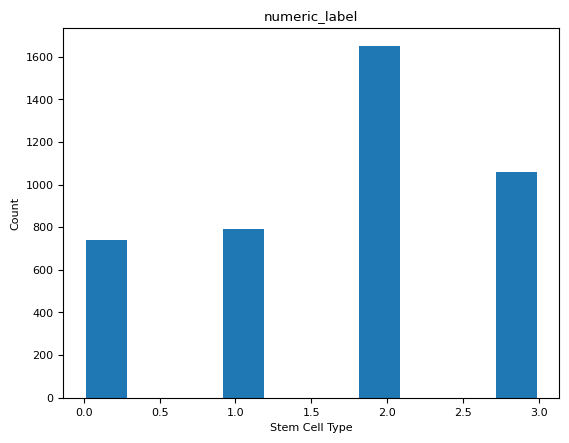

In [183]:
# # tcga_1st_round_combined.groupby(['numeric_label']).count()

# scs = ["hESC", "hMSC", "hUSC", "iPSC"]
# axarr = tcga_1st_round_combined.hist(column='numeric_label',  grid=False, zorder=2, rwidth=0.9, label=scs)

# # tcga_1st_round_combined.groupby(['numeric_label']).hist(alpha=0.7, label='numeric_label')

# for ax in axarr.flatten():
#     ax.set_xlabel("Stem Cell Type")
#     ax.set_ylabel("Count")

Reading combined file takes around 28 secs

In [93]:
combined_stmfr_tcga_labeled = pd.read_csv('/Users/bhavesh/Library/CloudStorage/GoogleDrive-bhavesh.neekhra_phd18@ashoka.edu.in/My Drive/CR_Data/Results/MLCB/combined_stmfr_tcga_labelled.csv')

In [82]:
combined_stmfr_tcga_labeled_df = combined_stmfr_tcga_labeled

In [95]:
tcga_labeled_df = combined_stmfr_tcga_labeled.loc[combined_stmfr_tcga_labeled['Unnamed: 0'].str.contains('TCGA')==True]
tcga_labeled_df.set_index(tcga_labeled_df['Unnamed: 0'], inplace=True)
tcga_labeled_df.drop('Unnamed: 0', axis=1, inplace=True)


/var/folders/rf/3w2r5qss4cg6yvzsxmr48cl00000gn/T/ipykernel_804/1084887241.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tcga_labeled_df.drop('Unnamed: 0', axis=1, inplace=True)


In [ ]:
# combined_stmfr_tcga_labeled_df.set_index(combined_stmfr_tcga_labeled_df['Unnamed: 0'], inplace=True)
# combined_stmfr_tcga_labeled_df.drop('Unnamed: 0', axis=1, inplace=True)

In [ ]:
combined_stmfr_tcga_labeled_df

In [ ]:
combined_stmfr_tcga_labeled_df.columns

In [ ]:
# tcga_labeled_df = combined_stmfr_tcga_labeled_df.loc[combined_stmfr_tcga_labeled_df['Unnamed: 0'].str.contains('TCGA')==True]
# tcga_labeled_df.set_index(tcga_labeled_df['Unnamed: 0'], inplace=True)
# tcga_labeled_df.drop('Unnamed: 0', axis=1, inplace=True)

In [ ]:
tcga_labeled_df

Train-test on various combination on STMFR and TCGA 

In [ ]:
# combined_stmfr_tcga_labeled_df
# df

In [ ]:
# df.shape, tcga_labeled_df.shape

# Train on STMFR and test on TCGA

# X_train = df.iloc[:, :-1]
# y_train = df['numeric_label']

# X_test = tcga_labeled_df.iloc[:, :-1]
# y_test = tcga_labeled_df['numeric_label']

# Train on TCGA and test on STMFR

# X_train = tcga_labeled_df.iloc[:, :-1]
# y_train = tcga_labeled_df['numeric_label']

# X_test = df.iloc[:, :-1]
# y_test = df['numeric_label']

# Train-test on combined STMFR+TCGA

# train, test = train_test_split(combined_stmfr_tcga_labeled_df, test_size=0.2, random_state=42, shuffle=True) 
# X_train, y_train = train.iloc[:, :-1], train['numeric_label']
# X_test, y_test = test.iloc[:, :-1], test['numeric_label']

# Train on combined STMFR (50%)+TCGA and test on 50% STMFR

# stmfr_train_df, stmfr_test_df = train_test_split(df, test_size=0.5, random_state=42, shuffle=True)

# train_df = pd.concat([tcga_labeled_df, stmfr_train_df], ignore_index=True)

# X_train = train_df.iloc[:, :-1]
# y_train = train_df['numeric_label']

# X_test = stmfr_test_df.iloc[:, :-1]
# y_test = stmfr_test_df['numeric_label']

# Train on combined STMFR+TCGA(50%) and test on 50% TCGA


tcga_train_df, tcga_test_df = train_test_split(tcga_labeled_df, test_size=0.5, random_state=42, shuffle=True)

train_df = pd.concat([df, tcga_train_df], ignore_index=True)

X_train = train_df.iloc[:, :-1]
y_train = train_df['numeric_label']

X_test = tcga_test_df.iloc[:, :-1]
y_test = tcga_test_df['numeric_label']



model = LogisticRegression(n_jobs=-1, max_iter=250)

# fit model
model.fit(X_train, y_train)
# make predictions
predictions = model.predict(X_test)

target_names = ['hESC', 'hMSC', 'hUSC', 'iPSC']
# print(classification_report(y_test, predictions, target_names=target_names))

accuracy = accuracy_score(y_test, predictions)
# acc_list.append(accuracy)

b_accuracy = balanced_accuracy_score(y_test, predictions)
# b_acc_list.append(b_accuracy)

f1score = f1_score(y_test, predictions, average='weighted')
# f1_list.append(f1score)

precision = precision_score(y_test, predictions, average='weighted')
# prec_list.append(precision)

recall = recall_score(y_test, predictions, average='weighted')
# rec_list.append(recall)

print(accuracy, end='\t')
print(b_accuracy, end='\t')
print(f1score, end='\t')
print(precision, end='\t')
print(recall)



In [ ]:
x = tcga_labeled_df.iloc[:, :-1]
y = tcga_labeled_df['numeric_label']


skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for train_index, test_index in skf.split(x, y):
    
    X_train, X_test = x.iloc[train_index], x.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    model = LogisticRegression(n_jobs=-1, max_iter=250)

    # fit model
    model.fit(X_train, y_train)
    # make predictions
    predictions = model.predict(X_test)

    target_names = ['hESC', 'hMSC', 'hUSC', 'iPSC']
    # print(classification_report(y_test, predictions, target_names=target_names))

    accuracy = accuracy_score(y_test, predictions)
    # acc_list.append(accuracy)

    b_accuracy = balanced_accuracy_score(y_test, predictions)
    # b_acc_list.append(b_accuracy)

    f1score = f1_score(y_test, predictions, average='weighted')
    # f1_list.append(f1score)

    precision = precision_score(y_test, predictions, average='weighted')
    # prec_list.append(precision)

    recall = recall_score(y_test, predictions, average='weighted')
    # rec_list.append(recall)

    print(accuracy, end='\t')
    print(b_accuracy, end='\t')
    print(f1score, end='\t')
    print(precision, end='\t')
    print(recall)



# pca_n_components=100
# pca=True

# train, test = train_test_split(tcga_labeled_df, test_size=0.1, random_state=42, shuffle=True)

# X_train, y_train = train.iloc[:, :-1], train['numeric_label']
# X_test, y_test = test.iloc[:, :-1], test['numeric_label']

# print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

# if pca:
        
#     pca = PCA(n_components=pca_n_components)
#     X_train_pca = pca.fit_transform(X_train)
#     X_test_pca = pca.transform(X_test)
#     # tcga_pca = pca.transform(tcga)
    
#     model = LinearSVC(dual = False, max_iter=10000)
# else:
#     X_train_pca = X_train
#     X_test_pca = X_test
#     # tcga_pca = tcga

#     model = LinearSVC(dual = True, max_iter=10000)

 
# model.fit(X_train_pca, y_train)
# predictions = model.predict(X_test_pca)


# report = classification_report(y_test, predictions, output_dict=True)

# model_acc = accuracy_score(y_test, predictions, normalize=True)

In [ ]:
# model_acc

0.924190800681431

In [ ]:
# stmfr_pca = pca.transform(df.iloc[:, :-1])
# stmfr_predictions = model.predict(stmfr_pca)
# model_acc_stmfr = accuracy_score(df['numeric_label'], stmfr_predictions, normalize=True)

In [ ]:
# model_acc_stmfr

0.7975106253794778

In [18]:
def plot_comparison(accuracy_site1, accuracy_site2, accuracy_site3, accuracy_site4, accuracy_site5,
                    combined_accuracy_test_site1, combined_accuracy_test_site2, combined_accuracy_test_site3, combined_accuracy_test_site4, combined_accuracy_test_site5,
                    fname):

    sites = ("site 1", "site 2", "site 3", "site 4", "site 5")
    accuracy = {
        'Individual Model': (accuracy_site1, accuracy_site2, accuracy_site3, accuracy_site4, accuracy_site5),
        'Combined Model': (combined_accuracy_test_site1, combined_accuracy_test_site2, combined_accuracy_test_site3, combined_accuracy_test_site4, combined_accuracy_test_site5),
    }


    # print("\n\n",accuracy_site1, accuracy_site2, accuracy_site3, accuracy_site4, accuracy_site5, "\n\n",
    #       combined_accuracy_test_site1, combined_accuracy_test_site2, combined_accuracy_test_site3, combined_accuracy_test_site4, combined_accuracy_test_site5,
    #       "\n\n")

    x = np.arange(len(sites))  # the label locations
    width = 0.25  # the width of the bars
    multiplier = 0

    fig, ax = plt.subplots(layout='constrained')

    for attribute, measurement in accuracy.items():
        # print("Printing:",attribute, measurement)
        offset = width * multiplier
        rects = ax.bar(x + offset, measurement, width, label=attribute)
        ax.bar_label(rects, padding=0, rotation=60, fmt='{:,.2f}')
        multiplier += 1

    ax.set_ylabel('Accuracy')
    # ax.set_title(title)
    # ax.set_title('Model Performance RS = '+f'{random_state}')
    ax.set_xticks(x + width, sites)

    # ax.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
    ax.legend(loc='upper left', ncols=3)
    ax.set_ylim(0.0, 1.2)

    plt.show()

    # fig_name = "random_state_"+f'{random_state}'+".png"
    fig.savefig(fname)
    plt.close(fig)

In [1]:
!pwd

/Users/bhavesh/Documents/AU/PhD/model_agreement_expr/gitrepo/model_agreement


In [11]:
derived_stmfr_test_df = pd.read_csv("../../Rounds/Reverse/s")

FileNotFoundError: [Errno 2] No such file or directory: '../../Rounds/Reverse/derived_stmfr_test_probs.csv'